In [1]:
pip install -U finance-datareader

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 kB 1.3 MB/s eta 0:00:00


In [45]:
# mq_quant.py

import FinanceDataReader as fdr
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.ticker as mticker
import warnings
import seaborn as sns
sns.set_theme()


warnings.simplefilter(action='ignore', category=FutureWarning)

def get_close(ticker, start, end=None):
    """
    종가 데이터 수집 (Get Close Prices)
    """
    return fdr.DataReader(ticker, start, end)['Close']

def calc_daily_return(prices):
    """
    일별 수익률 계산 (Calculate Daily Returns)
    """
    return prices.pct_change().fillna(0)

def calc_cum_return(prices):
    """
    누적 수익률(자산 흐름) 계산 (Calculate Cumulative Returns)
    """
    return prices / prices.iloc[0]

def calc_portfolio(prices, weight=None):
    """
    포트폴리오 수익률 계산 (Calculate Portfolio Returns)
    returns: (일별 수익률, 누적 수익률)
    """
    # 1. 누적 수익률 계산
    cum_ret = calc_cum_return(prices)

    # 2. 비중 설정 (기본값: 동일 비중)
    if not weight:
        weight = [1/len(prices.columns)] * len(prices.columns)

    # 3. 포트폴리오 누적 수익률 (가중 평균)
    # 각 자산의 누적 수익률에 비중을 곱해 합산합니다. (Buy & Hold 가정)
    port_cum_ret = (cum_ret * weight).sum(axis=1)

    # 4. 포트폴리오 일별 수익률 (역산)
    port_daily_ret = port_cum_ret.pct_change().fillna(0)

    return port_daily_ret, port_cum_ret


def evaluate_performance(daily_ret, cum_ret, risk_free_rate=0.02):
    """
    성과 지표 평가 (CAGR, MDD, Volatility, Sharpe ratio)
    """

    # 1. 수익성 (CAGR)
    total_ret = cum_ret.iloc[-1]
    years = len(cum_ret) / 252
    cagr = total_ret ** (1 / years) - 1

    # 2. 안정성 (MDD)
    historical_max = cum_ret.cummax()
    dd = (cum_ret - historical_max) / historical_max * 100
    mdd = dd.min()

    # 3. 위험 (변동성)
    daily_vol = daily_ret.std()               # 일일 변동성
    annual_vol = daily_vol * np.sqrt(252)     # 연간 변동성

    # 4. 효율 (Sharpe Ratio)
    annual_return = daily_ret.mean() * 252    # 연간 수익률 (산술 평균)
    sharpe_ratio = (annual_return - risk_free_rate) / annual_vol # 위험 한 단위당 수익

    print(f"▶ 최종 수익률   : {(cum_ret.iloc[-1]-1)*100:.2f}%")
    print(f"=== 성과 평가 리포트 ===")
    print(f"1. 수익성 (CAGR) : {cagr*100:.2f}%")
    print(f"2. 안정성 (MDD)  : {mdd:.2f}%")
    print(f"-" * 30)
    print(f"3. 연간 변동성   : {annual_vol*100:.2f}%")
    print(f"4. 샤프 지수     : {sharpe_ratio:.4f}")

    return cagr, dd, mdd

def get_rebalancing_dates(close_data, period="month"):
    """
    리밸런싱 날짜 추출 (Pandas Grouper 활용)
    - 입력: 종가 데이터, 주기('month', 'quarter', 'year')
    - 출력: 리밸런싱 시행일(DatetimeIndex)
    """
    # 주기별 Pandas Frequency 문자열 매핑
    freq_map = {'month': 'ME', 'quarter': 'QE', 'year': 'YE'}

    # 1. 예외처리: 잘못된 주기 입력
    if period not in freq_map:
        raise ValueError("period must be 'month', 'quarter', or 'year'")

    freq = freq_map[period]

    rebalancing_dates = close_data.groupby(pd.Grouper(freq=freq)).apply(lambda x: x.index[-1])

    return rebalancing_dates.sort_index()


def cal_rebalancing_portfolio(close_data, period="month", weight_df=None, enable_plot=True):
    """
    리밸런싱 포트폴리오 성과 계산 (Chunk 방식)
    """

    # 1. 리밸런싱 날짜 구하기 (전체 데이터 기준)
    rebal_dates = get_rebalancing_dates(close_data, period)

    # 날짜 동기화 (weight_df가 있다면, 교집합 날짜만 사용)
    # close_data가 더 길어도, weight_df가 있는 기간만 백테스팅 수행
    if weight_df is not None:
        # weight_df 인덱스에 포함된 날짜만 필터링
        rebal_dates = rebal_dates[rebal_dates.isin(weight_df.index)]

        # 만약 겹치는 날짜가 하나도 없다면 에러 처리
        if rebal_dates.empty:
            print("Error: close_data와 weight_df의 리밸런싱 날짜가 일치하지 않습니다.")
            return None, None

    # 3. 초기 비중 설정 (없으면 동일 비중)
    if weight_df is None:
        n_assets = len(close_data.columns)
        weight_df = pd.DataFrame(
            index=rebal_dates,
            columns=close_data.columns,
            data=1/n_assets
        )

    # 4. 데이터 범위 보정 (시작일 기준)
    first_date = rebal_dates[0] # 필터링된 첫 날짜


    # 전체 기간 수익률 계산
    full_daily_rets = close_data.pct_change().fillna(0)

    # 백테스트 시작일 이후 데이터만 슬라이싱
    daily_rets = full_daily_rets.loc[first_date:]

    portfolio_chunks = []
    total_value = 1.0

    # 리밸런싱 기간별 순회
    full_dates = list(rebal_dates)

    # 마지막 구간 처리: 마지막 리밸런싱 날짜 ~ 데이터 끝 날짜
    # (단, daily_rets의 마지막 날짜가 리밸런싱 날짜보다 뒤에 있을 때만)
    if full_dates[-1] < daily_rets.index[-1]:
        full_dates.append(daily_rets.index[-1])

    for start, end in zip(full_dates[:-1], full_dates[1:]):

        # start가 weight_df에 없으면 건너뜀 (안전 장치)
        if start not in weight_df.index:
            continue

        current_weights = weight_df.loc[start]

        # start 다음날부터 end까지의 수익률 사용 (start 당일은 리밸런싱 날)
        chunk_rets = daily_rets.loc[start:end].iloc[1:]

        if chunk_rets.empty: continue

        cum_growth = (1 + chunk_rets).cumprod()
        chunk_value = (cum_growth * current_weights).sum(axis=1) * total_value
        portfolio_chunks.append(chunk_value)
        total_value = chunk_value.iloc[-1]

    # 6. 결과 병합
    if not portfolio_chunks:
        return None, None

    portfolio_cum_ret = pd.concat(portfolio_chunks)
    portfolio_cum_ret.loc[first_date] = 1.0 # 시작점 1.0 강제 할당
    portfolio_cum_ret = portfolio_cum_ret.sort_index()

    portfolio_day_ret = portfolio_cum_ret.pct_change().fillna(0)

    if enable_plot:
        historical_max = portfolio_cum_ret.cummax()
        dd = (portfolio_cum_ret - historical_max) / historical_max * 100
        mdd = dd.min()

        # [수정] 전체 컬럼이 아니라, weight_df에 존재하는(실제 투자된) 티커만 추출
        if weight_df is not None:
            # weight_df의 컬럼 중 close_data에도 존재하는 것만 리스트로 만듦 (KeyError 방지)
            tickers = [col for col in weight_df.columns if col in close_data.columns]

            if 'cash' in tickers: tickers.remove('cash')
        else:
            tickers = close_data.columns.tolist()

        plot_daily_rets = full_daily_rets.loc[portfolio_cum_ret.index]

        plot_portfolio_result(tickers, plot_daily_rets, portfolio_cum_ret, dd, mdd)

    return portfolio_day_ret, portfolio_cum_ret


def plot_portfolio_result(tickers, daily_rets, port_cum_ret, dd, mdd):
    """
    포트폴리오 성과 시각화 함수 (백테스트 기간 일치 버전)
    """

    plt.figure(figsize=(10, 8))

    # [차트 1] 포트폴리오 누적 수익률 (Asset Growth)
    plt.subplot(2, 1, 1)

    # 1. 메인 포트폴리오 선 그리기
    plt.plot(port_cum_ret.index, port_cum_ret, label='Portfolio', color='#d62728', linewidth=1.5)

    # 2. 개별 종목 흐름 그리기 (기간 매칭 및 리베이스)
    if daily_rets is not None and tickers is not None:

        # [핵심 수정] 포트폴리오의 시작/종료 날짜 구하기
        start_date = port_cum_ret.index[0]
        end_date = port_cum_ret.index[-1]

        # [핵심 수정] 전체 데이터(daily_rets)를 실제 백테스트 기간만큼만 자르기
        subset_daily_rets = daily_rets.loc[start_date:end_date]

        for t in tickers:
            if t in subset_daily_rets.columns:
                # [핵심 수정] 잘라낸 기간의 수익률로 누적 수익률 새로 계산
                # 이렇게 해야 시작점이 1.0(혹은 포트폴리오 시작점) 근처로 맞춰집니다.
                ind_cum = (1 + subset_daily_rets[t]).cumprod()

                # 시각화 (투명도 조절)
                plt.plot(ind_cum.index, ind_cum, label=f'{t}', alpha=0.3, linewidth=0.8, linestyle='--')

    # Y축 로그 스케일 및 포맷 설정
    plt.yscale('log')
    ax = plt.gca()
    ax.yaxis.set_major_formatter(mticker.ScalarFormatter())
    ax.yaxis.set_minor_formatter(mticker.ScalarFormatter())
    ax.ticklabel_format(style='plain', axis='y')

    plt.axhline(1.0, color='gray', linestyle=':', alpha=0.5)
    plt.title('Portfolio Cumulative Return', fontsize=14, fontweight='bold')

    # 범례가 너무 많으면 가리니까, 적절히 위치 조정
    plt.legend(loc='upper left', fontsize='small')
    plt.grid(True, alpha=0.3)


    # [차트 2] 낙폭 (Drawdown)
    plt.subplot(2, 1, 2)

    plt.fill_between(dd.index, dd, 0, color='#1f77b4', alpha=0.3)
    plt.plot(dd.index, dd, color='#1f77b4', linewidth=0.5)

    plt.title('Portfolio Drawdown (MDD)', fontsize=12)
    plt.axhline(mdd, color='red', linestyle='--', label=f'Max DD: {mdd:.2f}%')

    plt.legend(loc='lower right')
    plt.grid(True, alpha=0.3)
    plt.ylabel('Drawdown (%)')

    plt.tight_layout()
    plt.show()

def cal_AvgMomentumScore(close_data, n = 12):
    """
    평균 모멘텀 스코어를 기반으로 한 투자 비중 구하기
    close_data: 종가 데이터
    n: 모멘텀 기간 1~n
    return: 투자비중 weight df, 평균모멘텀 스코어 df
    """
    avgMomentumScore = 0 # 평모스 초기값
    priceOnRebalDate = close_data.loc[get_rebalancing_dates(close_data)] # 리밸런싱 일자의 가격 데이터

    # 1 ~ n개월 모멘텀 스코어 합
    for i in range(1, n+1):
        avgMomentumScore = np.where(priceOnRebalDate / priceOnRebalDate.shift(i) > 1, 1, 0) + avgMomentumScore

    # 평모스 계산
    avgMomentumScore = pd.DataFrame(avgMomentumScore, index=priceOnRebalDate.index, columns=priceOnRebalDate.columns) # dataframe 형변환
    avgMomentumScore = avgMomentumScore / n

    # 모멘텀 스코어에 따른 weight 계산
    weight = avgMomentumScore.divide(avgMomentumScore.sum(axis=1), axis=0).fillna(0)
    # 투자 비중이 모두 0인 구간에서는 현금 보유
    weight['cash'] = np.where(weight.sum(axis=1) == 0, 1, 0)

    # 투자비중, 평모스 리턴
    return weight, avgMomentumScore

def get_heatmap(cumReturn):
    """
    cagr, dd, mdd 계산 및 히트맵(연간/월간 수익률) 시각화
    """
    # 1. CAGR 계산
    cagr = cumReturn.iloc[-1] ** (252/len(cumReturn))

    # 2. MDD 계산
    dd = (cumReturn.cummax() - cumReturn) / cumReturn.cummax() * 100
    mdd = dd.max()

    print(f"최종수익률: {cumReturn.iloc[-1]:.4f}\ncagr: {cagr:.4f}\nmdd: {mdd:.4f}%")

    # 3. 데이터프레임 변환 및 전처리
    cumReturn = pd.DataFrame(cumReturn)
    cumReturn.columns = ['cumReturn']
    cumReturn['year'] = cumReturn.index.year
    cumReturn['month'] = cumReturn.index.month

    # 월별/연별 마지막 데이터만 추출
    monthData = cumReturn.drop_duplicates(['year', 'month'], keep="last").copy()
    yearData = cumReturn.drop_duplicates('year', keep="last").copy()

    # 4. 수익률 계산
    monthData['monthReturn'] = monthData['cumReturn'].pct_change().fillna(0) * 100
    # 연간 수익률
    yearData['yearReturn'] = yearData['cumReturn'].pct_change().fillna(0) * 100
    # 첫 해 수익률 보정 (1.0에서 시작했다고 가정)
    yearData.iloc[0, -1] = (yearData.iloc[0, 0] - 1) * 100

    # 시각화를 위해 마지막 데이터의 '월'을 강제로 12로 설정 (연간 수익률 히트맵 정렬용)
    yearData.iloc[-1, yearData.columns.get_loc('month')] = 12

    # 5. 히트맵 시각화
    # 피벗 테이블 생성
    monthPivot = monthData.pivot(index='year', columns='month', values='monthReturn')
    yearPivot = yearData.pivot(index='year', columns='month', values='yearReturn')

    # 그래프 그리기
    # width_ratios=[1, 5]: 연간 수익률(왼쪽)은 좁게, 월간 수익률(오른쪽)은 넓게 설정
    f, (ax1, ax2) = plt.subplots(1, 2, sharey=True, gridspec_kw={'width_ratios': [1, 5]}, figsize=(20, 10))

    # 왼쪽: 연간 수익률
    sns.heatmap(yearPivot, ax=ax1, annot=True, fmt='.2f', linewidths=.3, cmap="RdYlGn", center=0, cbar=False)
    ax1.set_title("Annual Return")

    # 오른쪽: 월간 수익률
    sns.heatmap(monthPivot, ax=ax2, annot=True, fmt='.2f', linewidths=.1, cmap="RdYlGn", center=0, cbar=False)
    ax2.set_title("Monthly Return")

    plt.tight_layout()
    plt.show()

### 실제 주식 매매 단위와 거래 수수료 반영

In [35]:
# 데이터 로드
stock = get_close("069500", "2013") # 코스피200 ETF
bond = get_close("152380", "2013") # kodex 국고채 10년물 etf

close_data = pd.concat([stock, bond], axis=1)
close_data.columns = ['stock', 'bond']
close_data.dropna(inplace=True)
close_data

,stock,bond
Date,,
2013-10-25,21174,54496
2013-10-28,21356,54397
2013-10-29,21439,54397
2013-10-30,21522,54481
2013-10-31,21197,54362
...,...,...
2026-01-08,66620,68045
2026-01-09,67180,67705
2026-01-12,67610,67685


In [37]:
# 리밸런싱 날짜
rebalancingDate = get_rebalancing_dates(close_data)

# 리밸런싱 비율, 동일비중으로 가정
portfolioWeight = [0.5, 0.5]
weightDf = pd.DataFrame([portfolioWeight] * len(rebalancingDate), index=rebalancingDate, columns=close_data.columns)
weightDf

,stock,bond
2013-10-31,0.5,0.5
2013-11-29,0.5,0.5
2013-12-30,0.5,0.5
2014-01-29,0.5,0.5
2014-02-28,0.5,0.5
...,...,...
2025-09-30,0.5,0.5
2025-10-31,0.5,0.5
2025-11-28,0.5,0.5
2025-12-30,0.5,0.5


In [103]:
#초기 세팅
totalAsset = 10_000_000 # 초기 자본금, 1000만원 가정
prevQuantity = 0  #이전에 보유했던 자본 수량(처음에는 0)

portfolio = pd.DataFrame() # 결과를 담을 표
start = rebalancingDate.iloc[0] #리밸런싱 날짜, 초기값 첫 투자일

# 슬리피지율 설정 (보통 0.1% ~ 0.5%)
# 유동성이 좋은 대형주는 0.001(0.1%), 소형주는 0.005(0.5%) 정도 잡습니다.
broker_fee = 0.00015  # 증권사 수수료 (0.015% 가정)
tax_rate = 0.0020    # 증권거래세 + 농특세(0.2%)
slippage_rate= 0.002  # 슬리피지(0.2%)

In [104]:
# 초기화 (중복 실행 시 꼬임 방지)
portfolio = pd.DataFrame()
totalAsset = 10_000_000 # 초기 자본금 1000만원
prevQuantity = 0
start = rebalancingDate.iloc[0] # 시작일 초기화

# 리밸런싱 루프 시작 & 구매 수량 계산 (Allocation)
for end in rebalancingDate[1:]:
    weight = weightDf.loc[start] # 당기 리밸런싱 비율(50:50)

    capacity = totalAsset * weight # 리밸런싱 비율에 따른 자산별 배정금액

    priceData = close_data.loc[start: end] # 이번 리밸런싱 기간의 가격 데이터

    # 데이터가 없는 경우 예외처리
    if priceData.empty:
        continue


    priceOnRebalDay = priceData.iloc[0] # 리밸런싱 당일(첫) 가격

    quantity = capacity // priceOnRebalDay #  주식은 0.5주를 살 수 없으므로, 주가에 맞춰 살수 있는 최대 정수 수량

    # 거래 비용 및 잔돈 계산
    diffQuantity = quantity - prevQuantity # 실제 매매해야하는 수량((이번 달 목표 - 지난 달 보유)), 양수-> 매수, 음수 -> 매도

    # 거래금액 (절대값)
    trade_amount = abs(diffQuantity) * priceOnRebalDay

    # 증권사 수수료 (매매 금액의 0.015%)
    total_brokerage = (trade_amount * broker_fee).sum()

    # 세금 (매도 금액의 0.2%)
    # diffQuantity가 음수(매도)인 종목만 계산
    sell_amount = trade_amount[diffQuantity < 0]
    total_tax = (sell_amount * tax_rate).sum()

    # 슬리피지 (매매 금액의 0.2%)
    total_slippage = (trade_amount * slippage_rate).sum()

    # 총 비용 합산
    total_cost = total_brokerage + total_tax + total_slippage

    # 잔여 현금 계산
    # (배정된 금액 - 실제 주식 매수액 - 총 비용)
    # 주의: capacity는 '주식+현금'을 포함한 배정액이므로, 실제 남은 현금은 capacity - 주식매수액 - 비용
    leftCash = (capacity - quantity * priceOnRebalDay).sum() - total_cost

    # 보유 자산의 일별 평가액 흐름 (주식 수 * 매일매일의 가격)
    assetFlow = quantity * priceData

    # 이번 구간 마지막 날의 주식 평가액 합계
    valueOnLastDay = assetFlow.iloc[-1].sum()

    # 자산 흐름에 '현금(leftCash)' 컬럼 추가
    assetFlow['leftCash'] = round(leftCash, 2)
    portfolio = pd.concat([portfolio, assetFlow])

    # 다음 달 투자를 위한 자산 갱신 (주식 평가액 + 현금)
    totalAsset = (valueOnLastDay + leftCash)
    prevQuantity = quantity
    start = end

portfolio

,stock,bond,leftCash
Date,,,
2013-10-31,4981295.0,4946942.0,50417.29
2013-11-01,4994690.0,4931199.0,50417.29
2013-11-04,4955680.0,4918641.0,50417.29
2013-11-05,4928420.0,4929015.0,50417.29
2013-11-06,4932415.0,4893889.0,50417.29
...,...,...,...
2026-01-08,10659200.0,9798480.0,81624.99
2026-01-09,10748800.0,9749520.0,81624.99
2026-01-12,10817600.0,9746640.0,81624.99


In [105]:
# 매달 마지막 영업일엔 리밸런싱이 들어간 row만 남긴다.
portfolio = portfolio.loc[~portfolio.index.duplicated(keep='last')]
portfolio

,stock,bond,leftCash
Date,,,
2013-10-31,4981295.0,4946942.0,50417.29
2013-11-01,4994690.0,4931199.0,50417.29
2013-11-04,4955680.0,4918641.0,50417.29
2013-11-05,4928420.0,4929015.0,50417.29
2013-11-06,4932415.0,4893889.0,50417.29
...,...,...,...
2026-01-08,10659200.0,9798480.0,81624.99
2026-01-09,10748800.0,9749520.0,81624.99
2026-01-12,10817600.0,9746640.0,81624.99


In [106]:
# 포트폴리오 자산흐름
portfolioAssetFlow = portfolio.sum(axis=1)
portfolioAssetFlow

,0
Date,
2013-10-31,9978654.29
2013-11-01,9976306.29
2013-11-04,9924738.29
2013-11-05,9907852.29
2013-11-06,9876721.29
...,...
2026-01-08,20539304.99
2026-01-09,20579944.99
2026-01-12,20645864.99


In [107]:
dayReturn = calc_daily_return(portfolioAssetFlow)
dayReturn

,0
Date,
2013-10-31,0.000000
2013-11-01,-0.000235
2013-11-04,-0.005169
2013-11-05,-0.001701
2013-11-06,-0.003142
...,...
2026-01-08,0.000588
2026-01-09,0.001979
2026-01-12,0.003203


In [108]:
# 누적 수익률
cumReturn = portfolioAssetFlow / portfolioAssetFlow.iloc[0]
cumReturn

,0
Date,
2013-10-31,1.000000
2013-11-01,0.999765
2013-11-04,0.994597
2013-11-05,0.992905
2013-11-06,0.989785
...,...
2026-01-08,2.058324
2026-01-09,2.062397
2026-01-12,2.069003


In [113]:
# 수수료 고려 결과 확인

# 1. 중복 제거 (리밸런싱 날짜 기준)
portfolio_clean = portfolio.loc[~portfolio.index.duplicated(keep='last')]

# 2. 자산 흐름 합계
portfolioAssetFlow = portfolio_clean.sum(axis=1)

# 3. 누적 수익률 & 일별 수익률
cumReturn = portfolioAssetFlow / portfolioAssetFlow.iloc[0]
dayReturn = calc_daily_return(portfolioAssetFlow)

# 4. 성과 평가
_,_,_ = evaluate_performance(dayReturn , cumReturn)

▶ 최종 수익률   : 107.76%
=== 성과 평가 리포트 ===
1. 수익성 (CAGR) : 6.34%
2. 안정성 (MDD)  : -25.22%
------------------------------
3. 연간 변동성   : 9.05%
4. 샤프 지수     : 0.5041


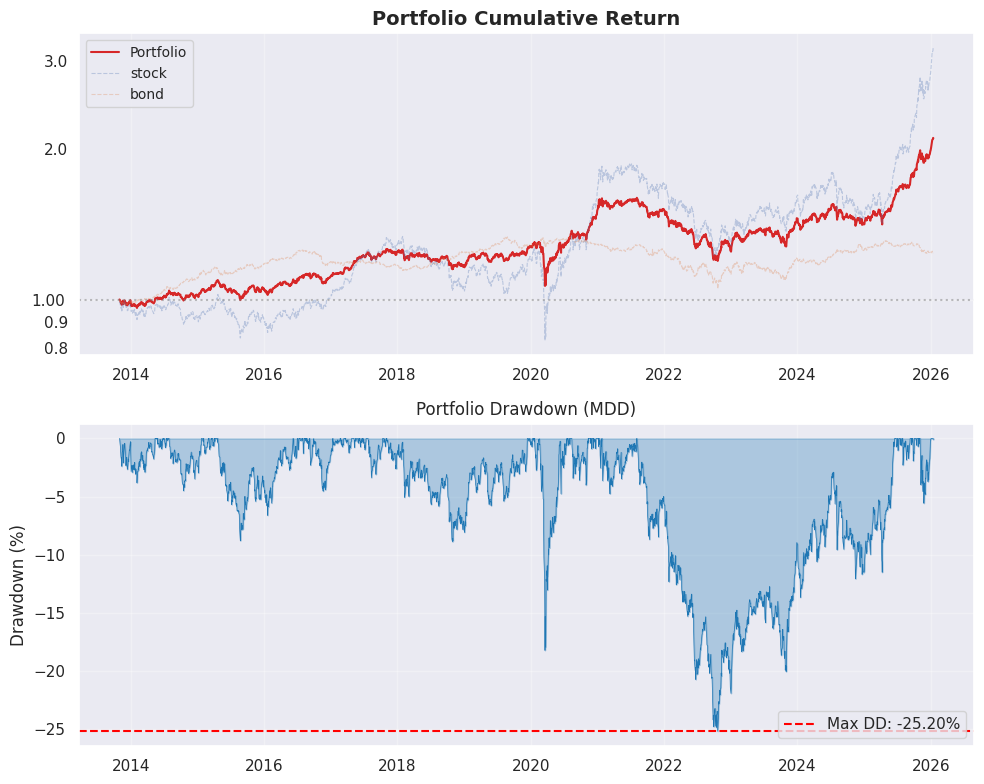

▶ 최종 수익률   : 110.11%
=== 성과 평가 리포트 ===
1. 수익성 (CAGR) : 6.44%
2. 안정성 (MDD)  : -25.20%
------------------------------
3. 연간 변동성   : 9.07%
4. 샤프 지수     : 0.5135


In [114]:
# 수수료 고려 X
dayReturnWithoutFee, cumReturnWithoutFee = cal_rebalancing_portfolio(close_data=close_data, weight_df=weightDf, enable_plot=True)
_,_,_ = evaluate_performance(dayReturnWithoutFee , cumReturnWithoutFee)

### 함수화



In [111]:
def cal_rebalancing_portfolio_Fee(close_data, totalAsset, period = "month", weightDf=None):

    # 자산별 비중. 기본값: 동일비중
    if weightDf is None:
        rebalancingDate = get_rebalancing_dates(close_data, period) # 리밸런싱 날짜
        weightDf = pd.DataFrame([[1/len(close_data.columns)] * len(close_data.columns)] * len(rebalancingDate),
                              index=rebalancingDate,
                              columns=close_data.columns)
    else:
        rebalancingDate = weightDf.index # 리밸런싱 날짜

    totalAsset = totalAsset # 초기 자본금
    prevQuantity = 0 # 초기 자산 보유량

    quantityDf = pd.DataFrame() # 시기별 각 자산 보유량을 담을 데이터프레임
    portfolio = pd.DataFrame() # 전체 자산흐름을 담을 데이터프레임

    broker_fee = 0.00015  # 증권사 수수료 (0.015% 가정)
    tax_rate = 0.0020    # 증권거래세 + 농특세 (0.20%)
    slippage_rate= 0.002  # 슬리피지(0.2%)

    start = rebalancingDate.iloc[0] # 리밸런싱 날짜, 초기값 첫 투자일

    for end in rebalancingDate[1:]:
        weight = weightDf.loc[start] # 당기 리밸런싱 비율

        capacity = totalAsset * weight # 리밸런싱 비율에 따른 자산별 가용액,

        priceData = close_data.loc[start: end] # 당기 가격 데이터

        if priceData.empty:
            continue

        priceOnRebalDay = priceData.iloc[0] # 리밸런싱 당일 가격

        quantity = capacity // priceOnRebalDay # 이번달 capacity에 따라 실제 보유 해야 할 주식수

        # 거래 비용 및 잔돈 계산
        diffQuantity = quantity - prevQuantity # 실제 매매해야하는 수량, 양수-> 매수, 음수 -> 매도

        # 거래금액 (절대값)
        trade_amount = abs(diffQuantity) * priceOnRebalDay

        # 증권사 수수료
        total_brokerage = (trade_amount * broker_fee).sum()

        # 세금 (매도 금액의 0.2%)
        sell_amount = trade_amount[diffQuantity < 0]
        total_tax = (sell_amount * tax_rate).sum()

        # 슬리피지
        total_slippage = (trade_amount * slippage_rate).sum()

        # 총 비용 합산
        total_cost = total_brokerage + total_tax + total_slippage

        # 잔여 현금 계산
        leftCash = (capacity - quantity * priceOnRebalDay).sum() - total_cost

        assetFlow = quantity * priceData # 수량*가격 = 각 자산 흐름
        valueOnLastDay = assetFlow.iloc[-1].sum() # 월말 평가액

        assetFlow['leftCash'] = round(leftCash, 2)
        portfolio = pd.concat([portfolio, assetFlow]) # 자산 흐름 데이터프레임에 추가


        totalAsset = (valueOnLastDay + leftCash)
        prevQuantity = quantity # 이전 자산 보유량 업데이트

        start = end # 리밸런싱 날짜 업데이트

    # 매달 마지막 영업일엔 리밸런싱이 들어간 row만 남긴다.
    portfolio = portfolio.loc[~portfolio.index.duplicated(keep='last')]
    # 포트폴리오 자산흐름
    portfolioAssetFlow = portfolio.sum(axis=1)
    # 누적 수익률
    cumReturn = portfolioAssetFlow / portfolioAssetFlow.iloc[0]
    # 일간 수익률
    dayReturn = cumReturn.pct_change().fillna(0)

    return dayReturn, cumReturn

In [112]:
dayReturn, cumReturn = cal_rebalancing_portfolio_Fee(close_data=close_data, totalAsset=10_000_000)
_ = evaluate_performance(dayReturn, cumReturn)

▶ 최종 수익률   : 107.76%
=== 성과 평가 리포트 ===
1. 수익성 (CAGR) : 6.34%
2. 안정성 (MDD)  : -25.22%
------------------------------
3. 연간 변동성   : 9.05%
4. 샤프 지수     : 0.5041
